In [1]:
# %%
# ============= BLOQUE 0 — Imports & Config (una sola fuente de verdad) =============
import os, re, glob, time, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --- Config dataset ---
DATA_DIR         = "./data/ALPHAEARTH/2019"          # ALPHA_*.npy y (opcional) MASK_*_128.npy
PASTIS_ANN_ROOT  = "../PASTIS/PASTIS/ANNOTATIONS"    # TARGET_*.npy
PATCH_SIZE       = 128
CHANNELS         = 64

# --- Etiquetas ---
NUM_CLASSES      = 18          # clases efectivas 0..17
IGNORE_INDEX     = 255         # 0 y 19 -> ignore
IGNORED_LABELS   = {0, 19}

# --- Entrenamiento ---
SEED             = 1337
BATCH_SIZE       = 16
EPOCHS           = 2
LR               = 3e-4
WD               = 1e-4
MAX_GRAD_NORM    = 1.0
AMP_ENABLED      = True

# --- DataLoader (Windows/notebook safe) ---
NUM_WORKERS      = 0
PIN_MEMORY       = False

# --- Augmentations ---
AUG_FLIP_ROT     = True
AUG_CUTOUT       = True
AUG_INTENSITY    = True

# --- Visualización RGB sintético ---
BANDS_RGB        = (0, 31, 63)

# --- Modelo: 'unet' o 'deeplabv3_64' ---
MODEL_NAME       = 'deeplabv3_64'  # 'unet' o 'deeplabv3_64'

# --- Semillas & device ---
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Device: cuda


In [2]:
# %%
# ============= BLOQUE 1 — Utilidades IO, normalización, remapeo, augs, RGB =========

def load_alpha(fp, channels=CHANNELS):
    """Carga ALPHA como [H,W,C]. Acepta [H,W,C] o [C,H,W]. Reemplaza rellenos -9999 por NaN."""
    X = np.load(fp)
    if X.ndim != 3:
        raise ValueError(f'Alpha dims inválidas: {X.shape}')
    if X.shape[0] == channels and X.shape[-1] != channels:
        X = np.moveaxis(X, 0, -1)             # [H,W,C]
    if X.shape[-1] != channels:
        raise ValueError(f'Alpha canales ≠ {channels}: {X.shape}')
    X = X.astype(np.float32)
    if np.any(X == -9999.0):
        X[X == -9999.0] = np.nan
    return X

def load_mask_any(fp):
    """Mask como [H,W] int64. Soporta (H,W), (1/3,H,W), (H,W,1/3), (20,H,W) o (H,W,20)."""
    M = np.load(fp)
    if M.ndim == 2:
        return M.astype(np.int64)
    if M.ndim == 3 and M.shape[0] in (1, 3):
        return M[0].astype(np.int64)
    if M.ndim == 3 and M.shape[-1] in (1, 3):
        return M[..., 0].astype(np.int64)
    if M.ndim == 3 and M.shape[0] == 20:
        return np.argmax(M, axis=0).astype(np.int64)
    if M.ndim == 3 and M.shape[-1] == 20:
        return np.argmax(M, axis=-1).astype(np.int64)
    raise ValueError(f"Máscara con dims inesperadas: {M.shape}")

def remap_labels_1to18_to_0to17_with_ignore(M):
    """0 y 19 -> 255; 1..18 -> 0..17."""
    out = np.full_like(M, IGNORE_INDEX, dtype=np.int64)
    mask = (M >= 1) & (M <= 18)
    out[mask] = M[mask] - 1
    return out

def center_crop_or_pad(img, th, tw, fill):
    """Centra a [th,tw], recortando o rellenando con 'fill'. Soporta [H,W] o [H,W,C]."""
    H, W = img.shape[:2]
    y0 = max((H - th)//2, 0); x0 = max((W - tw)//2, 0)
    y1 = y0 + min(th, H);     x1 = x0 + min(tw, W)
    cropped = img[y0:y1, x0:x1, ...]
    ph = th - cropped.shape[0]; pw = tw - cropped.shape[1]
    if ph > 0 or pw > 0:
        out = np.full([th, tw] + ([] if img.ndim == 2 else [img.shape[2]]), fill, dtype=img.dtype)
        oy = (th - cropped.shape[0])//2; ox = (tw - cropped.shape[1])//2
        out[oy:oy+cropped.shape[0], ox:ox+cropped.shape[1], ...] = cropped
        return out
    return cropped

def robust_minmax_per_channel(X, p_lo=2, p_hi=98):
    """Escala cada canal a [0,1] usando percentiles, ignorando NaNs."""
    H, W, C = X.shape
    Y = np.zeros_like(X, dtype=np.float32)
    for c in range(C):
        v = X[..., c]
        vv = v[~np.isnan(v)]
        if vv.size == 0:
            Y[..., c] = 0.0
            continue
        lo, hi = np.percentile(vv, [p_lo, p_hi])
        den = max(hi - lo, 1e-6)
        Y[..., c] = np.clip((v - lo) / den, 0, 1)
    return np.nan_to_num(Y, nan=0.0)

def apply_sync_fliprot(X, Y):
    """Flips/rot90 sincronizados (sin RNG por índice; cambia cada llamada)."""
    if AUG_FLIP_ROT:
        if np.random.rand() < 0.5:
            X = np.flip(X, 1).copy(); Y = np.flip(Y, 1).copy()   # horiz
        if np.random.rand() < 0.5:
            X = np.flip(X, 0).copy(); Y = np.flip(Y, 0).copy()   # vert
        k = np.random.randint(0, 4)
        if k:
            X = np.rot90(X, k, (0,1)).copy()
            Y = np.rot90(Y, k, (0,1)).copy()
    return X, Y

def aug_cutout(X, Y, p=0.35, max_boxes=2, box_frac=0.25):
    if AUG_CUTOUT and np.random.rand() < p:
        H, W = Y.shape
        for _ in range(np.random.randint(1, max_boxes+1)):
            bh = int(H * box_frac * (0.5 + np.random.rand()))
            bw = int(W * box_frac * (0.5 + np.random.rand()))
            y0 = np.random.randint(0, max(1, H - bh + 1))
            x0 = np.random.randint(0, max(1, W - bw + 1))
            X[y0:y0+bh, x0:x0+bw, :] = 0.0
    return X, Y

def aug_intensity(X, p_gain=0.5, p_noise=0.5, p_drop=0.25, max_drop=6):
    if not AUG_INTENSITY:
        return X
    if np.random.rand() < p_gain:
        gain = 0.9 + 0.2*np.random.rand()
        bias = (np.random.rand()-0.5)*0.05
        X = np.clip(X*gain + bias, 0.0, 1.0)
    if np.random.rand() < p_noise:
        sigma = 0.01 + 0.02*np.random.rand()
        X = np.clip(X + np.random.normal(0, sigma, size=X.shape).astype(np.float32), 0.0, 1.0)
    if np.random.rand() < p_drop:
        C = X.shape[-1]
        k = np.random.randint(1, max_drop+1)
        idx = np.random.choice(C, size=k, replace=False)
        X[..., idx] = 0.0
    return X

def to_rgb(X, picks=BANDS_RGB):
    rgb = np.zeros((X.shape[0], X.shape[1], 3), dtype=np.float32)
    for i, b in enumerate(picks):
        rgb[..., i] = np.clip(X[..., b], 0, 1)
    return rgb


In [3]:
# %%
# ============= BLOQUE 2 — Descubrir/validar pares (una vez) ========================

def find_pairs(alpha_dir=DATA_DIR, ann_root=PASTIS_ANN_ROOT):
    """Devuelve lista de (alpha_path, mask_path, pid). Usa MASK recortada si existe; si no, TARGET PASTIS."""
    pairs = []
    for ap in sorted(glob.glob(os.path.join(alpha_dir, 'ALPHA_*.npy'))):
        base = os.path.basename(ap)
        m = re.search(r'ALPHA_(\d+)\.npy$', base)
        if not m: 
            continue
        pid = m.group(1)
        mp1 = os.path.join(alpha_dir, f'MASK_{pid}_128.npy')
        mp2 = os.path.join(ann_root,  f'TARGET_{pid}.npy')
        mp  = mp1 if os.path.isfile(mp1) else (mp2 if os.path.isfile(mp2) else None)
        if mp is None:
            continue
        pairs.append((ap, mp, pid))
    return pairs

def validate_pairs_quick(pairs, sample=999999):
    good, bad = [], []
    for (ap, mp, pid) in pairs[:sample]:
        try:
            X = load_alpha(ap)
            M = load_mask_any(mp)
            if X.ndim != 3 or X.shape[-1] != CHANNELS:
                raise ValueError(f'Alpha shape {X.shape}')
            if M.ndim != 2:
                raise ValueError(f'Mask shape {M.shape}')
            good.append((ap, mp, pid))
        except Exception as e:
            bad.append((pid, str(e)))
    print(f'✔️ Válidos: {len(good)}   ⚠️ Omitidos: {len(bad)}')
    if bad:
        for pid,msg in bad[:10]: print(f'  - PID {pid}: {msg}')
    return good

pairs_all   = validate_pairs_quick(find_pairs())
random.Random(SEED).shuffle(pairs_all)
n            = len(pairs_all)
n_train      = int(0.7*n); n_val = int(0.15*n)
pairs_train  = pairs_all[:n_train]
pairs_val    = pairs_all[n_train:n_train+n_val]
pairs_test   = pairs_all[n_train+n_val:]
print(f"Pares: train={len(pairs_train)} | val={len(pairs_val)} | test={len(pairs_test)}")


✔️ Válidos: 2433   ⚠️ Omitidos: 0
Pares: train=1703 | val=364 | test=366


In [4]:
# ============= BLOQUE 3 — Dataset & DataLoaders (sin duplicar funciones) ===========
class PastisAEDataset(Dataset):
    def __init__(self, pairs, patch=PATCH_SIZE, train=True, norm='robust'):
        self.pairs = list(pairs)
        self.patch = patch
        self.train = train
        self.norm  = norm

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        ap, mp, pid = self.pairs[idx]
        X = load_alpha(ap)                # [H,W,64]
        M = load_mask_any(mp)             # [H,W] (0..19 o ya mapeada)
        # Centro a 128x128
        X = center_crop_or_pad(X, self.patch, self.patch, fill=np.nan).astype(np.float32)
        M = center_crop_or_pad(M, self.patch, self.patch, fill=IGNORE_INDEX).astype(np.int64)
        # Remapeo 1..18->0..17; 0/19->255
        Y = remap_labels_1to18_to_0to17_with_ignore(M)

        # Augs (solo train)
        if self.train:
            X, Y = apply_sync_fliprot(X, Y)
        # Normalización robusta SIEMPRE antes de intensidad
        X = robust_minmax_per_channel(X)
        if self.train:
            X, Y = aug_cutout(X, Y)
            X    = aug_intensity(X)

        # Tensores contiguos
        X = np.ascontiguousarray(X, dtype=np.float32)
        Y = np.ascontiguousarray(Y, dtype=np.int64)
        X = torch.from_numpy(np.transpose(X, (2,0,1)))   # [C,H,W]
        Y = torch.from_numpy(Y)                          # [H,W]
        return X, Y, pid

# DataLoaders
ds_train = PastisAEDataset(pairs_train, train=True)
ds_val   = PastisAEDataset(pairs_val,   train=False)
ds_test  = PastisAEDataset(pairs_test,  train=False)

dlt = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False)
dlv = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
dls = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                 num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Batches -> train={len(dlt)} | val={len(dlv)} | test={len(dls)}")


Batches -> train=107 | val=23 | test=23


In [5]:
# %%
# ============= BLOQUE 4 — Pesos de clase (una vez) ================================

def compute_class_weights_from_pairs(pairs, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX, mode='median'):
    counts = np.zeros(num_classes, dtype=np.int64)
    for _, mp, _ in pairs:
        m = load_mask_any(mp)
        y = remap_labels_1to18_to_0to17_with_ignore(m)
        v = y[y != ignore_index]
        if v.size == 0: 
            continue
        hist = np.bincount(v, minlength=num_classes)
        counts += hist[:num_classes]
    total = counts.sum()
    if total == 0:
        raise ValueError("Máscaras vacías al computar pesos.")
    freq = np.clip(counts/total, 1e-12, None)
    if mode == 'median':
        med = np.median(freq[freq > 0])
        w = med / freq
    elif mode == 'effective':
        beta = 0.9999
        w = (1 - beta) / (1 - np.power(beta, counts + 1e-6))
    else:
        w = 1.0 / np.sqrt(freq)
    w = (w / w.mean()).astype(np.float32)
    return w, counts

class_weights_np, class_counts = compute_class_weights_from_pairs(pairs_train)
print("Counts por clase:", class_counts.tolist())
print("Pesos normalizados:", np.round(class_weights_np, 3).tolist())


Counts por clase: [5108688, 1940741, 2400469, 545448, 500539, 174879, 267921, 774963, 234783, 202393, 309491, 273127, 83557, 452032, 285264, 276749, 142920, 117624]
Pesos normalizados: [0.050999999046325684, 0.13500000536441803, 0.10899999737739563, 0.48100000619888306, 0.5239999890327454, 1.5010000467300415, 0.9800000190734863, 0.33899998664855957, 1.1180000305175781, 1.2970000505447388, 0.8479999899864197, 0.9610000252723694, 3.1410000324249268, 0.5809999704360962, 0.9200000166893005, 0.9480000138282776, 1.8359999656677246, 2.2309999465942383]


In [6]:
# ============= BLOQUE 5 — Pérdidas y Métricas (definidas una vez) =================
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

ce_loss = nn.CrossEntropyLoss(weight=class_weights_t, ignore_index=IGNORE_INDEX, label_smoothing=0.05)

def soft_dice_loss(logits, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX, eps=1e-6):
    valid = (target != ignore_index)
    if valid.sum() == 0:
        return logits.new_tensor(0.0)
    probs = F.softmax(logits, dim=1).permute(0,2,3,1)[valid]  # [N,C]
    onehot = F.one_hot(target[valid], num_classes=num_classes).float()
    inter  = (probs * onehot).sum(dim=0)
    denom  = probs.sum(dim=0) + onehot.sum(dim=0)
    dice   = (2*inter + eps) / (denom + eps)
    return 1.0 - dice.mean()

W_DICE = 0.5
def total_loss(logits, target):
    lce   = torch.nan_to_num(ce_loss(logits, target),   nan=0.0, posinf=1e4, neginf=0.0)
    ldice = torch.nan_to_num(soft_dice_loss(logits, target), nan=0.0, posinf=1e4, neginf=0.0)
    return lce + W_DICE*ldice

@torch.no_grad()
def compute_confmat(pred, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    valid = (target != ignore_index)
    pred  = pred[valid]; target = target[valid]
    if target.numel() == 0:
        return torch.zeros((num_classes, num_classes), dtype=torch.int64, device=pred.device)
    k = (target * num_classes + pred).to(torch.int64)
    return torch.bincount(k, minlength=num_classes**2).reshape(num_classes, num_classes)

def iou_from_confmat(cm):
    tp = cm.diag().float()
    fp = cm.sum(0).float() - tp
    fn = cm.sum(1).float() - tp
    denom = tp + fp + fn
    iou = torch.where(denom > 0, tp / torch.clamp(denom, min=1e-6), torch.nan)
    return iou, torch.nanmean(iou)

def pixel_accuracy(cm):
    return (cm.diag().sum().float() / torch.clamp(cm.sum().float(), min=1e-6)).item()


In [7]:
# ============= BLOQUE 6 — Modelos (elige con MODEL_NAME) ==========================
from torchvision.models.segmentation import deeplabv3_resnet50

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        else:
            self.up = nn.ConvTranspose2d(in_ch//2, in_ch//2, 2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        dy = x2.size(2) - x1.size(2)
        dx = x2.size(3) - x1.size(3)
        if dy or dx:
            x1 = F.pad(x1, [dx//2, dx-dx//2, dy//2, dy-dy//2])
        return self.conv(torch.cat([x2, x1], dim=1))

class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 1)
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=CHANNELS, n_classes=NUM_CLASSES, bilinear=True):
        super().__init__()
        f = 64
        self.inc   = DoubleConv(n_channels, f)
        self.down1 = Down(f,   f*2)
        self.down2 = Down(f*2, f*4)
        self.down3 = Down(f*4, f*8)
        self.down4 = Down(f*8, f*8)
        self.up1   = Up(f*16, f*4, bilinear)
        self.up2   = Up(f*8,  f*2, bilinear)
        self.up3   = Up(f*4,  f,   bilinear)
        self.up4   = Up(f*2,  f,   bilinear)
        self.outc  = OutConv(f, n_classes)
    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2); x4 = self.down3(x3); x5 = self.down4(x4)
        x  = self.up1(x5, x4); x = self.up2(x, x3); x = self.up3(x, x2); x = self.up4(x, x1)
        return self.outc(x)

def make_deeplabv3_resnet50_64in(num_classes=NUM_CLASSES, channels=CHANNELS):
    model = deeplabv3_resnet50(weights=None, aux_loss=False, num_classes=num_classes)
    # localizar conv1
    if hasattr(model.backbone, 'body') and hasattr(model.backbone.body, 'conv1'):
        conv1 = model.backbone.body.conv1
        model.backbone.body.conv1 = nn.Conv2d(channels, conv1.out_channels,
                                              kernel_size=conv1.kernel_size,
                                              stride=conv1.stride,
                                              padding=conv1.padding,
                                              bias=False)
        nn.init.kaiming_normal_(model.backbone.body.conv1.weight, mode='fan_out', nonlinearity='relu')
    elif hasattr(model.backbone, 'conv1'):
        conv1 = model.backbone.conv1
        model.backbone.conv1 = nn.Conv2d(channels, conv1.out_channels,
                                         kernel_size=conv1.kernel_size,
                                         stride=conv1.stride,
                                         padding=conv1.padding,
                                         bias=False)
        nn.init.kaiming_normal_(model.backbone.conv1.weight, mode='fan_out', nonlinearity='relu')
    else:
        raise RuntimeError("No se encontró conv1 en el backbone.")
    return model

def build_model():
    if MODEL_NAME == 'unet':
        net = UNet(n_channels=CHANNELS, n_classes=NUM_CLASSES).to(device)
        return net, lambda out: out
    elif MODEL_NAME == 'deeplabv3_64':
        net = make_deeplabv3_resnet50_64in(NUM_CLASSES).to(device)
        return net, (lambda out: out['out'])
    else:
        raise ValueError("MODEL_NAME debe ser 'unet' o 'deeplabv3_64'")

model, get_logits = build_model()


In [8]:
# ============= BLOQUE 7 — Entrenamiento & Validación (sin duplicar lógica) =========
from torch.cuda.amp import autocast, GradScaler

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scaler    = GradScaler(enabled=(device.type=='cuda') and AMP_ENABLED)

steps_per_epoch = max(1, len(dlt))
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=steps_per_epoch
)

def train_one_epoch(epoch):
    model.train()
    t0, loss_acc, n = time.time(), 0.0, 0
    for X,Y,_ in dlt:
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)
        X = torch.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0).clamp_(0.0, 1.0)
        if (Y != IGNORE_INDEX).sum() == 0:
            continue
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(device.type=='cuda') and AMP_ENABLED):
            out    = model(X)
            logits = get_logits(out)
            if not torch.isfinite(logits).all():
                continue
            loss = total_loss(logits, Y)
        if not torch.isfinite(loss):
            continue
        scaler.scale(loss).backward()
        if MAX_GRAD_NORM:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        loss_acc += float(loss.detach().cpu()); n += 1
    return loss_acc / max(1,n), time.time()-t0

@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_acc, n = 0.0, 0
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)
    for X,Y,_ in loader:
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)
        X = torch.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0).clamp_(0.0, 1.0)
        if (Y != IGNORE_INDEX).sum() == 0:
            continue
        with autocast(enabled=(device.type=='cuda') and AMP_ENABLED):
            out    = model(X)
            logits = get_logits(out)
            loss   = total_loss(logits, Y)
        if torch.isfinite(loss):
            loss_acc += float(loss.detach().cpu()); n += 1
        preds = logits.argmax(1)
        cm_total += compute_confmat(preds, Y)
    iou, miou = iou_from_confmat(cm_total)
    acc = pixel_accuracy(cm_total)
    return (loss_acc/max(1,n)), float(miou.item()), float(acc)

# Smoke test
with torch.no_grad():
    xb,yb,_ = next(iter(dlv))
    xb = xb.to(device); yb = yb.to(device)
    out = model(xb); logits = get_logits(out); lt = total_loss(logits, yb)
    print("✅ Smoke test | val loss:", float(lt.detach().cpu()))

# Loop
stamp = time.strftime("%Y%m%d_%H%M%S")
os.makedirs("./checkpoints", exist_ok=True)
ckpt_best = f'./checkpoints/{MODEL_NAME}_best_{stamp}.pt'
best = -1.0

print(f"Entrenando ({MODEL_NAME}) por {EPOCHS} épocas…")
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_time = train_one_epoch(epoch)
    va_loss, va_miou, va_acc = evaluate(dlv)
    print(f"[{epoch:03d}/{EPOCHS}] train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | mIoU={va_miou:.3f} | pixAcc={va_acc:.3f} | time={tr_time:.1f}s")
    if va_miou > best:
        best = va_miou
        torch.save({'model': model.state_dict(), 'epoch': epoch, 'best_miou': best}, ckpt_best)
        print(f"  ↳ 🥇 Nuevo best mIoU={best:.3f} @ {ckpt_best}")


C:\Users\LuisA\AppData\Local\Temp\ipykernel_16540\2770644453.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(device.type=='cuda') and AMP_ENABLED)


✅ Smoke test | val loss: 3.8027095794677734
Entrenando (deeplabv3_64) por 2 épocas…


C:\Users\LuisA\AppData\Local\Temp\ipykernel_16540\2770644453.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=='cuda') and AMP_ENABLED):
C:\Users\LuisA\AppData\Local\Temp\ipykernel_16540\2770644453.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=='cuda') and AMP_ENABLED):


[001/2] train_loss=3.3503 | val_loss=3.0211 | mIoU=0.161 | pixAcc=0.434 | time=125.7s
  ↳ 🥇 Nuevo best mIoU=0.161 @ ./checkpoints/deeplabv3_64_best_20251027_203130.pt
[002/2] train_loss=2.6026 | val_loss=2.3962 | mIoU=0.302 | pixAcc=0.621 | time=128.1s
  ↳ 🥇 Nuevo best mIoU=0.302 @ ./checkpoints/deeplabv3_64_best_20251027_203130.pt


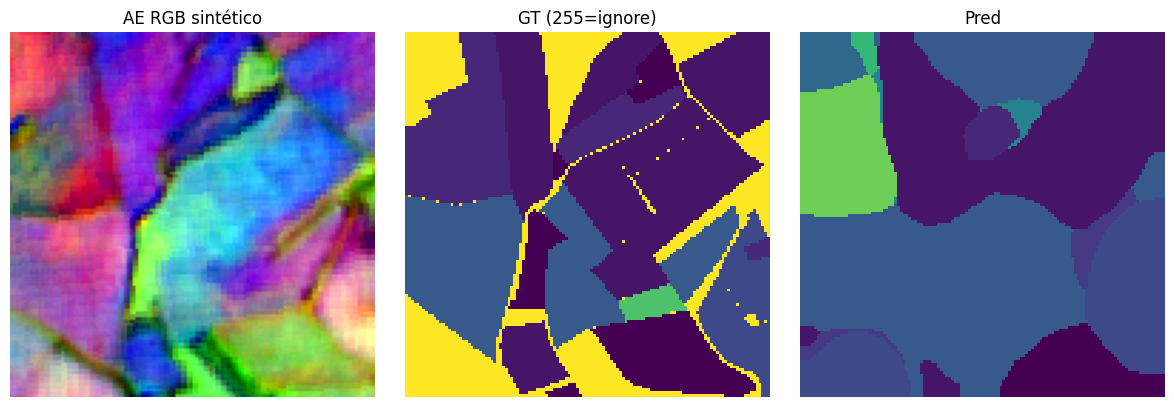

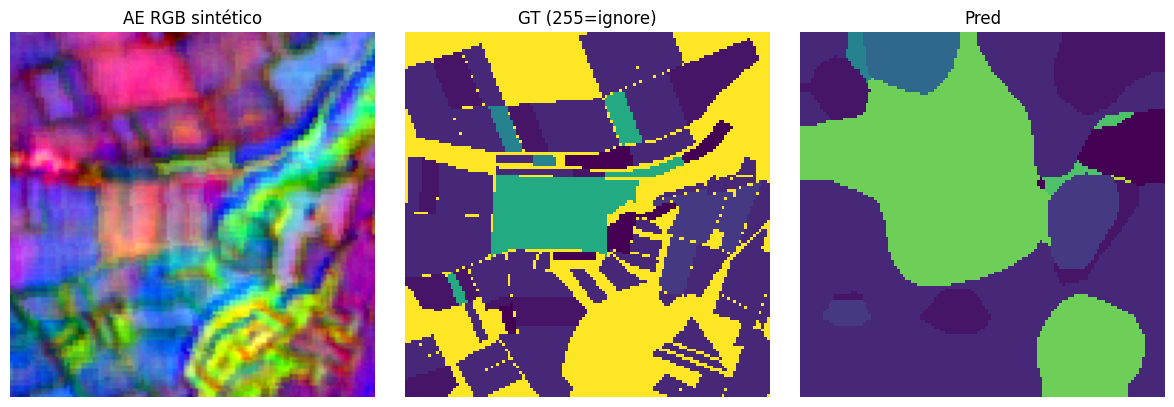

[TEST] loss=2.0247 | mIoU=0.297 | pixAcc=0.618


In [9]:
# ============= BLOQUE 8 — Visualización y Test (reutiliza utilidades) =============
@torch.no_grad()
def visualize_batch(loader, n=2):
    model.eval()
    Xb, Yb, _ = next(iter(loader))
    Xb = Xb.to(device); Yb = Yb.to(device)
    out    = model(Xb)
    logits = get_logits(out)
    preds  = logits.argmax(1)
    Xb = Xb.cpu().numpy(); Yb = Yb.cpu().numpy(); preds = preds.cpu().numpy()
    for i in range(min(n, Xb.shape[0])):
        x = np.transpose(Xb[i], (1,2,0))
        rgb = to_rgb(x)
        y  = Yb[i]; p = preds[i]
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(rgb); plt.title('AE RGB sintético'); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(y, vmin=0, vmax=NUM_CLASSES, interpolation='nearest'); plt.title('GT (255=ignore)'); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(p, vmin=0, vmax=NUM_CLASSES, interpolation='nearest'); plt.title('Pred'); plt.axis('off')
        plt.tight_layout(); plt.show()

visualize_batch(dlv, n=2)

# Métricas en TEST
@torch.no_grad()
def eval_test(loader):
    model.eval()
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)
    losses = []
    for X,Y,_ in loader:
        X = X.to(device); Y = Y.to(device)
        out    = model(X)
        logits = get_logits(out)
        losses.append(float(ce_loss(logits, Y).detach().cpu()))
        cm_total += compute_confmat(logits.argmax(1), Y)
    iou, miou = iou_from_confmat(cm_total)
    acc = pixel_accuracy(cm_total)
    return np.mean(losses), float(miou.item()), float(acc), iou.detach().cpu().numpy()

test_loss, test_miou, test_acc, iou_per_class = eval_test(dls)
print(f"[TEST] loss={test_loss:.4f} | mIoU={test_miou:.3f} | pixAcc={test_acc:.3f}")
